# 17 — 2mu2e ABCD working-point comparison

Compare three isolation boundaries without a threshold scan:

- WP1: `(Mu-LJ, EGM-LJ) = (0.25, 0.25)`
- WP2: `(Mu-LJ, EGM-LJ) = (0.50, 0.25)`
- WP3: `(Mu-LJ, EGM-LJ) = (0.50, 0.40)`

The comparison combines MC SR closure, MC/Data VR-invDisplaced closure, pull, non-prompt signal contamination, and relative SR-A signal yield. Data SR A is never accessed. For the current presentation, WP1 $(0.25, 0.25)$ is the declared choice; the final choice may also depend on factors outside this comparison.

In [1]:
import gc
import re
import sys
from pathlib import Path

search_roots = [Path.cwd(), *Path.cwd().parents]
SIDM_DIR = next((path for path in search_roots if path.name == "sidm"), None)
assert SIDM_DIR is not None, "Could not locate the sidm repository root"
if str(SIDM_DIR.parent) not in sys.path:
    sys.path.insert(1, str(SIDM_DIR.parent))

import coffea.util
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

if int(np.__version__.split(".")[0]) < 2:
    import numpy.core as _numpy_core
    import numpy.core.numeric as _numpy_numeric
    sys.modules.setdefault("numpy._core", _numpy_core)
    sys.modules.setdefault("numpy._core.numeric", _numpy_numeric)

%matplotlib inline


## 1. Inputs and working points

In [2]:
STUDY_DIR = SIDM_DIR / "studies/ABCD_Study"
BKG_INPUT_DIR = STUDY_DIR / "ABCD_golden_hotspot_iso025_v1_bkg_merged_samples_v1"
DATA_INPUT_DIR = STUDY_DIR / "ABCD_golden_hotspot_iso025_v1_data_merged_samples_v1"
SIGNAL_INPUT_DIR = STUDY_DIR / "ABCD_golden_hotspot_iso025_v1_signal_merged_samples_v1"
HIST_NAME = "mulj_egmlj_iso"
X_LABEL = "Mu-LJ Isolation"
Y_LABEL = "EGM-LJ Isolation"
BACKGROUND_ORDER = ["QCD", "DY", "TTJets", "Diboson"]
WP_CONFIGS = {
    "WP1 (0.25, 0.25)": (0.25, 0.25),
    "WP2 (0.50, 0.25)": (0.50, 0.25),
    "WP3 (0.50, 0.40)": (0.50, 0.40),
}
CHANNELS = {
    "SR": "test_SR_2mu2e_spread_cosAlpha_mu_veto",
    "VR-invDisplaced": "test_VR_2mu2e_invDisplaced_spread_cosAlpha_mu_veto",
}
TARGETS = (
    ("SR", "BKG total", "MC SR"),
    ("VR-invDisplaced", "BKG total", "MC VR"),
    ("VR-invDisplaced", "Data", "Data VR"),
)
assert not any(selection == "SR" and group == "Data" for selection, group, _ in TARGETS)


In [3]:
def classify_sample(sample):
    if sample.startswith("DoubleMuon"): return "Data"
    if sample.startswith("QCD_"): return "QCD"
    if sample.startswith("DYJetsTo"): return "DY"
    if sample.startswith("TTJets"): return "TTJets"
    if sample in {"WW", "WZ", "ZZ"}: return "Diboson"
    return "Other"

def load_hist(path):
    loaded = coffea.util.load(path)
    payload = loaded.get("out", loaded)[path.stem]
    return payload["hists"][HIST_NAME]

background_paths = sorted(BKG_INPUT_DIR.glob("*.coffea"))
data_paths = sorted(DATA_INPUT_DIR.glob("DoubleMuon*.coffea"))
signal_paths = sorted(SIGNAL_INPUT_DIR.glob("2Mu2E_*.coffea"))
assert background_paths and data_paths and signal_paths

background_hists = {}
for path in background_paths:
    group = classify_sample(path.stem)
    if group in BACKGROUND_ORDER:
        background_hists.setdefault(group, []).append(load_hist(path))
data_hists = [load_hist(path) for path in data_paths]
signal_hists = {path.stem: load_hist(path) for path in signal_paths}
gc.collect()
print(f"Loaded {sum(map(len, background_hists.values()))} background, "
      f"{len(data_hists)} data, and {len(signal_hists)} signal payloads")


Loaded 18 background, 68 data, and 60 signal payloads


## 2. ABCD helpers

In [4]:
def sum_hists(hists):
    total = hists[0].copy()
    for hist in hists[1:]:
        total = total + hist
    return total

bkg_total = sum_hists([hist for group in BACKGROUND_ORDER for hist in background_hists.get(group, [])])
data_total = sum_hists(data_hists)

def plane(hist, selection):
    return hist[{"channel": CHANNELS[selection]}]

def target_hist(group, selection):
    return plane(data_total if group == "Data" else bkg_total, selection)

def values_variances(h2d):
    values = np.asarray(h2d.values(flow=True), dtype=float).copy()
    variances = h2d.variances(flow=True)
    variances = (np.clip(values, 0, None) if variances is None
                 else np.asarray(variances, dtype=float).copy())
    values[-2, :] += values[-1, :]; variances[-2, :] += variances[-1, :]
    values, variances = values[:-1, :], variances[:-1, :]
    values[:, -2] += values[:, -1]; variances[:, -2] += variances[:, -1]
    values, variances = values[:, :-1], variances[:, :-1]
    return values[1:, 1:], variances[1:, 1:]

def region_stats(h2d, cuts):
    values, variances = values_variances(h2d)
    x = np.asarray(h2d.axes[0].centers)[:, None]
    y = np.asarray(h2d.axes[1].centers)[None, :]
    masks = {
        "A": (x < cuts[0]) & (y < cuts[1]),
        "B": (x >= cuts[0]) & (y < cuts[1]),
        "C": (x < cuts[0]) & (y >= cuts[1]),
        "D": (x >= cuts[0]) & (y >= cuts[1]),
    }
    result = {}
    for region, mask in masks.items():
        value = float(values[mask].sum())
        variance = float(np.clip(variances[mask].sum(), 0, None))
        result[region] = {"yield": value, "error": np.sqrt(variance),
                          "neff": value**2 / variance if variance > 0 else np.nan}
    return result

def closure_row(h2d, cuts):
    stats = region_stats(h2d, cuts)
    b, c, d = (stats[r]["yield"] for r in "BCD")
    eb, ec, ed = (stats[r]["error"] for r in "BCD")
    pred = b * c / d if d > 0 else np.nan
    pred_err = (abs(pred) * np.sqrt((eb/b)**2 + (ec/c)**2 + (ed/d)**2)
                if b > 0 and c > 0 and d > 0 else np.nan)
    obs, obs_err = stats["A"]["yield"], stats["A"]["error"]
    kappa = obs / pred if pred > 0 else np.nan
    kappa_err = (abs(kappa) * np.sqrt((obs_err/obs)**2 + (pred_err/pred)**2)
                 if obs > 0 and pred > 0 else np.nan)
    denominator = np.sqrt(obs_err**2 + pred_err**2)
    row = {"A_pred": pred, "A_pred_err": pred_err, "kappa": kappa,
           "kappa_err": kappa_err,
           "pull": (obs-pred)/denominator if denominator > 0 else np.nan}
    for region in "ABCD":
        for field in ("yield", "error", "neff"):
            row[f"{region}_{field}"] = stats[region][field]
    return row


## 3. Control yields, closure, and pull

Inspect B/C/D and the prediction before comparing with A.

In [5]:
closure_rows = []
for wp, cuts in WP_CONFIGS.items():
    for selection, group, target in TARGETS:
        closure_rows.append({"wp": wp, "target": target,
                             **closure_row(target_hist(group, selection), cuts)})
closure_summary = pd.DataFrame(closure_rows)
control_columns = ["wp", "target", "B_yield", "B_error", "C_yield",
                   "C_error", "D_yield", "D_error", "A_pred", "A_pred_err"]
display(closure_summary[control_columns])
display(closure_summary[["wp", "target", "A_yield", "A_error",
                         "A_pred", "A_pred_err", "kappa", "kappa_err", "pull"]])


,wp,target,B_yield,B_error,C_yield,C_error,D_yield,D_error,A_pred,A_pred_err
0,"WP1 (0.25, 0.25)",MC SR,36.868713,11.275693,12.143459,8.080562,228.191738,138.441819,1.962007,1.865866
1,"WP1 (0.25, 0.25)",MC VR,1431.711980,208.852501,1574.024265,572.361765,3761.566297,383.899652,599.098679,242.558931
2,"WP1 (0.25, 0.25)",Data VR,1245.000000,35.284558,1690.000000,41.109610,3692.000000,60.761830,569.894366,23.259684
3,"WP2 (0.50, 0.25)",MC SR,34.483304,11.216530,91.497376,71.343839,148.837821,118.917994,21.198455,24.650043
4,"WP2 (0.50, 0.25)",MC VR,813.831995,132.475832,2943.109961,635.144633,2392.480600,267.522387,1001.135412,292.861611
5,"WP2 (0.50, 0.25)",Data VR,848.000000,29.120440,2920.000000,54.037024,2462.000000,49.618545,1005.751422,44.160217
6,"WP3 (0.50, 0.40)",MC SR,38.909545,11.704094,89.267183,71.334580,144.411579,118.870998,24.051711,28.525614
7,"WP3 (0.50, 0.40)",MC VR,1180.699269,169.321988,2269.947957,336.674610,2025.613326,245.862030,1323.118218,316.710631
8,"WP3 (0.50, 0.40)",Data VR,1211.000000,34.799425,2450.000000,49.497475,2099.000000,45.814845,1413.506432,58.457411


,wp,target,A_yield,A_error,A_pred,A_pred_err,kappa,kappa_err,pull
0,"WP1 (0.25, 0.25)",MC SR,31.003767,13.552784,1.962007,1.865866,15.802071,16.539297,2.122839
1,"WP1 (0.25, 0.25)",MC VR,522.082398,184.791147,599.098679,242.558931,0.871446,0.468643,-0.252570
2,"WP1 (0.25, 0.25)",Data VR,551.000000,23.473389,569.894366,23.259684,0.966846,0.057041,-0.571766
3,"WP2 (0.50, 0.25)",MC SR,33.389176,13.601789,21.198455,24.650043,1.575076,1.940675,0.433005
4,"WP2 (0.50, 0.25)",MC VR,1139.962383,245.392112,1001.135412,292.861611,1.138670,0.413561,0.363345
5,"WP2 (0.50, 0.25)",Data VR,948.000000,30.789609,1005.751422,44.160217,0.942579,0.051478,-1.072764
6,"WP3 (0.50, 0.40)",MC SR,35.619370,13.650262,24.051711,28.525614,1.480950,1.845840,0.365794
7,"WP3 (0.50, 0.40)",MC VR,1813.124388,591.841364,1323.118218,316.710631,1.370342,0.554687,0.729986
8,"WP3 (0.50, 0.40)",Data VR,1418.000000,37.656341,1413.506432,58.457411,1.003179,0.049305,0.064622


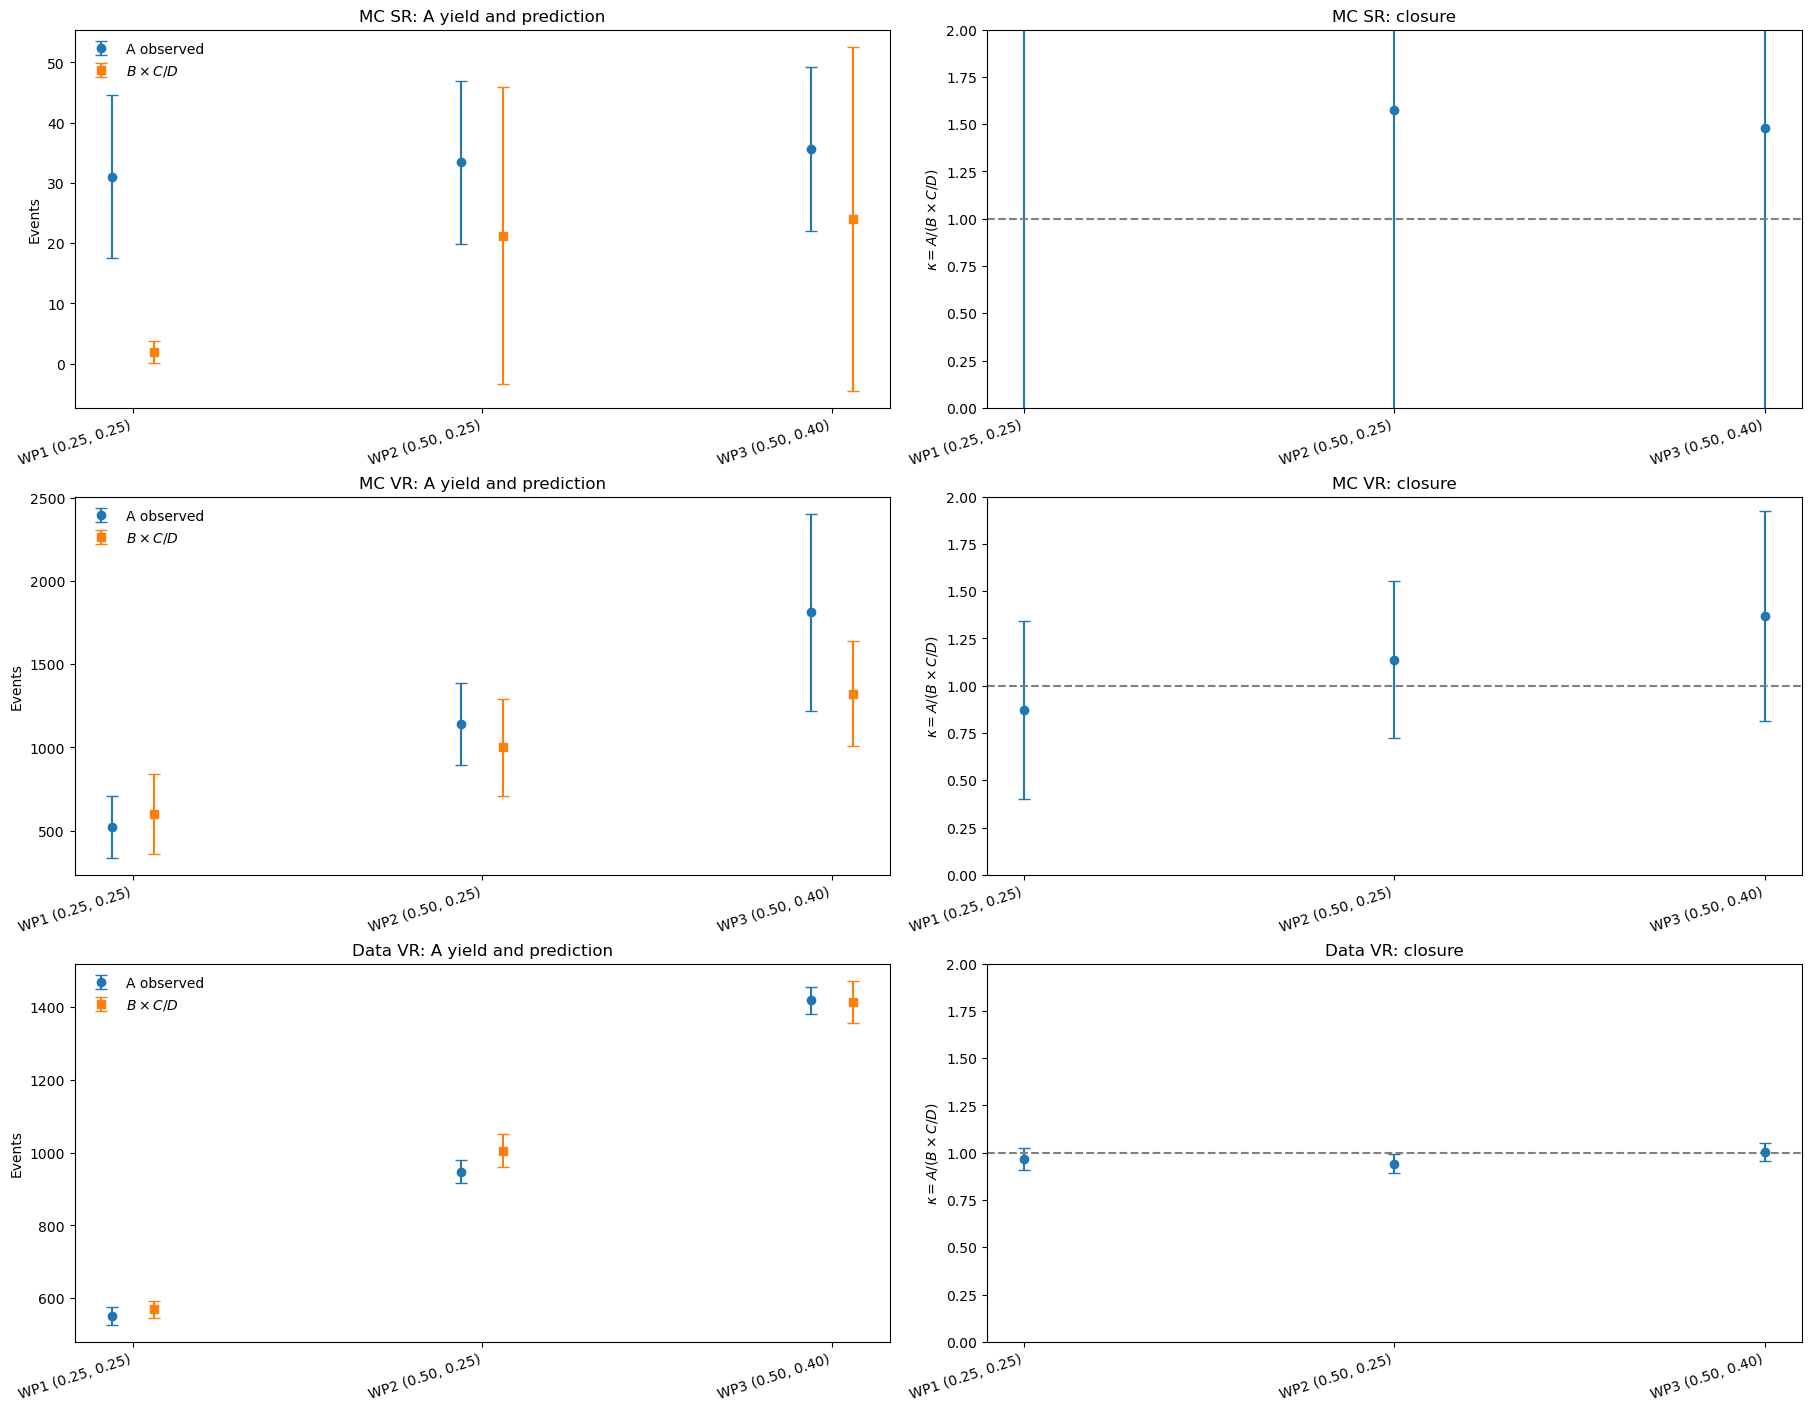

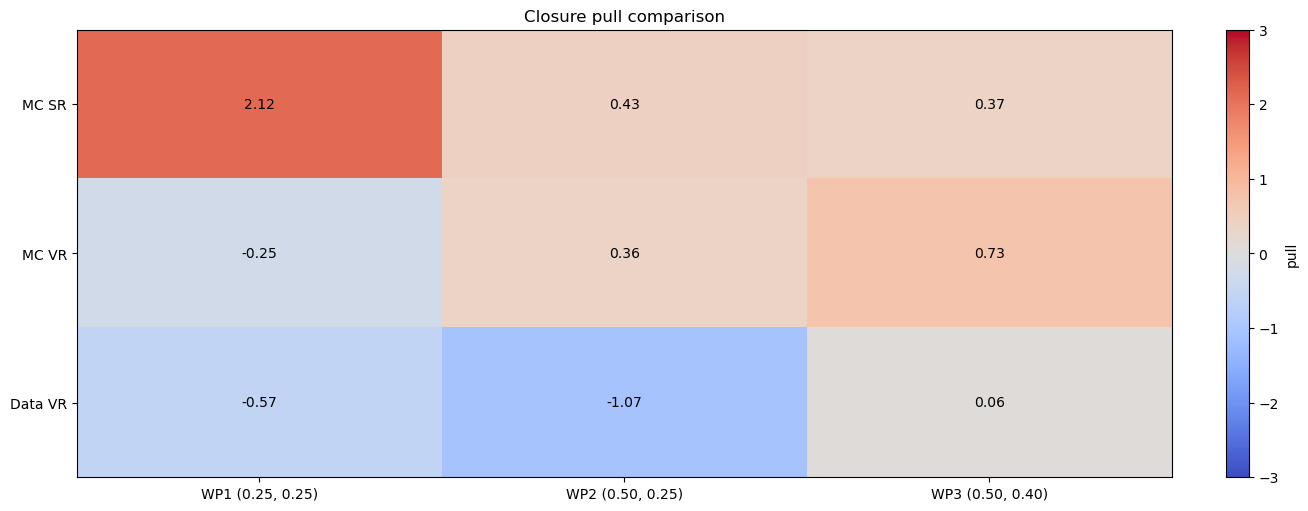

In [6]:
wp_labels = list(WP_CONFIGS)
fig, axes = plt.subplots(len(TARGETS), 2, figsize=(18, 14), constrained_layout=True)
for row_index, (_, _, target) in enumerate(TARGETS):
    frame = closure_summary[closure_summary.target == target].set_index("wp").loc[wp_labels]
    x = np.arange(len(frame))
    axes[row_index, 0].errorbar(x-0.06, frame.A_yield, yerr=frame.A_error,
                                fmt="o", capsize=4, label="A observed")
    axes[row_index, 0].errorbar(x+0.06, frame.A_pred, yerr=frame.A_pred_err,
                                fmt="s", capsize=4, label=r"$B \times C/D$")
    axes[row_index, 0].set(ylabel="Events", title=f"{target}: A yield and prediction")
    axes[row_index, 0].legend(frameon=False)
    axes[row_index, 1].errorbar(x, frame.kappa, yerr=frame.kappa_err,
                                 fmt="o", capsize=4)
    axes[row_index, 1].axhline(1, color="gray", linestyle="--")
    axes[row_index, 1].set(ylabel=r"$\kappa=A/(B \times C/D)$",
                           title=f"{target}: closure", ylim=(0, 2))
    for ax in axes[row_index]:
        ax.set_xticks(x, wp_labels, rotation=18, ha="right")
plt.show(); plt.close(fig)

pull_table = closure_summary.pivot(index="target", columns="wp", values="pull").loc[
    [target for _, _, target in TARGETS], wp_labels]
fig, ax = plt.subplots(figsize=(13, 5), constrained_layout=True)
image = ax.imshow(pull_table.values, cmap="coolwarm", vmin=-3, vmax=3, aspect="auto")
for i in range(len(pull_table.index)):
    for j in range(len(pull_table.columns)):
        ax.text(j, i, f"{pull_table.iloc[i,j]:.2f}", ha="center", va="center")
ax.set(xticks=range(len(wp_labels)), xticklabels=wp_labels,
       yticks=range(len(pull_table.index)), yticklabels=pull_table.index,
       title="Closure pull comparison")
plt.colorbar(image, ax=ax, label="pull")
plt.show(); plt.close(fig)


## 4. Signal contamination

The primary comparison excludes the shortest-lifetime $L_{xy}=0.3$ cm point in each mass grid. Results including those points are retained in the full table.

In [7]:
SIGNAL_PATTERN = re.compile(
    r"^2Mu2E_(?P<mA>[0-9p]+)GeV_(?P<mZd>[0-9p]+)GeV_(?P<ctau>[0-9p]+)mm$")

def decode(token): return float(token.replace("p", "."))

def signal_parameters(sample):
    fields = SIGNAL_PATTERN.match(sample).groupdict()
    return {key: decode(value) for key, value in fields.items()}

signal_rows = []
for sample, hist in signal_hists.items():
    pars = signal_parameters(sample)
    for wp, cuts in WP_CONFIGS.items():
        vr_signal = region_stats(plane(hist, "VR-invDisplaced"), cuts)
        vr_bkg = region_stats(plane(bkg_total, "VR-invDisplaced"), cuts)
        vr_data = region_stats(plane(data_total, "VR-invDisplaced"), cuts)
        sr_signal = region_stats(plane(hist, "SR"), cuts)
        row = {"signal": sample, **pars, "wp": wp,
               "SR_A_yield": sr_signal["A"]["yield"],
               "SR_A_fraction": sr_signal["A"]["yield"] /
                   sum(sr_signal[r]["yield"] for r in "ABCD")}
        for region in "ABCD":
            value = vr_signal[region]["yield"]
            row[f"VR_{region}_yield"] = value
            row[f"VR_{region}_BkgMC_yield"] = vr_bkg[region]["yield"]
            row[f"VR_{region}_Data_yield"] = vr_data[region]["yield"]
            row[f"VR_{region}_over_BkgMC"] = value / vr_bkg[region]["yield"]
            row[f"VR_{region}_over_Data"] = value / vr_data[region]["yield"]
        signal_rows.append(row)
signal_summary = pd.DataFrame(signal_rows)
signal_summary["lifetime_rank"] = signal_summary.groupby(
    ["wp", "mA", "mZd"])["ctau"].rank(method="dense").astype(int)
signal_summary["mean_Lxy_cm"] = signal_summary.lifetime_rank.map(
    {1: 0.3, 2: 3, 3: 30, 4: 150, 5: 300})
nonprompt_signal = signal_summary[signal_summary.lifetime_rank > 1].copy()

contamination_rows = []
for wp in wp_labels:
    frame = nonprompt_signal[nonprompt_signal.wp == wp]
    for region in "ABCD":
        contamination_rows.append({
            "wp": wp, "region": region,
            "max_S_over_BkgMC": frame[f"VR_{region}_over_BkgMC"].max(),
            "max_S_over_Data": frame[f"VR_{region}_over_Data"].max(),
        })
contamination_summary = pd.DataFrame(contamination_rows)
display(contamination_summary)


,wp,region,max_S_over_BkgMC,max_S_over_Data
0,"WP1 (0.25, 0.25)",A,0.157863,0.149578
1,"WP1 (0.25, 0.25)",B,0.000377,0.000434
2,"WP1 (0.25, 0.25)",C,0.003458,0.003221
3,"WP1 (0.25, 0.25)",D,0.000013,0.000014
4,"WP2 (0.50, 0.25)",A,0.072499,0.087180
5,"WP2 (0.50, 0.25)",B,0.000204,0.000196
6,"WP2 (0.50, 0.25)",C,0.001864,0.001878
7,"WP2 (0.50, 0.25)",D,0.000004,0.000004
8,"WP3 (0.50, 0.40)",A,0.045969,0.058778
9,"WP3 (0.50, 0.40)",B,0.000144,0.000141


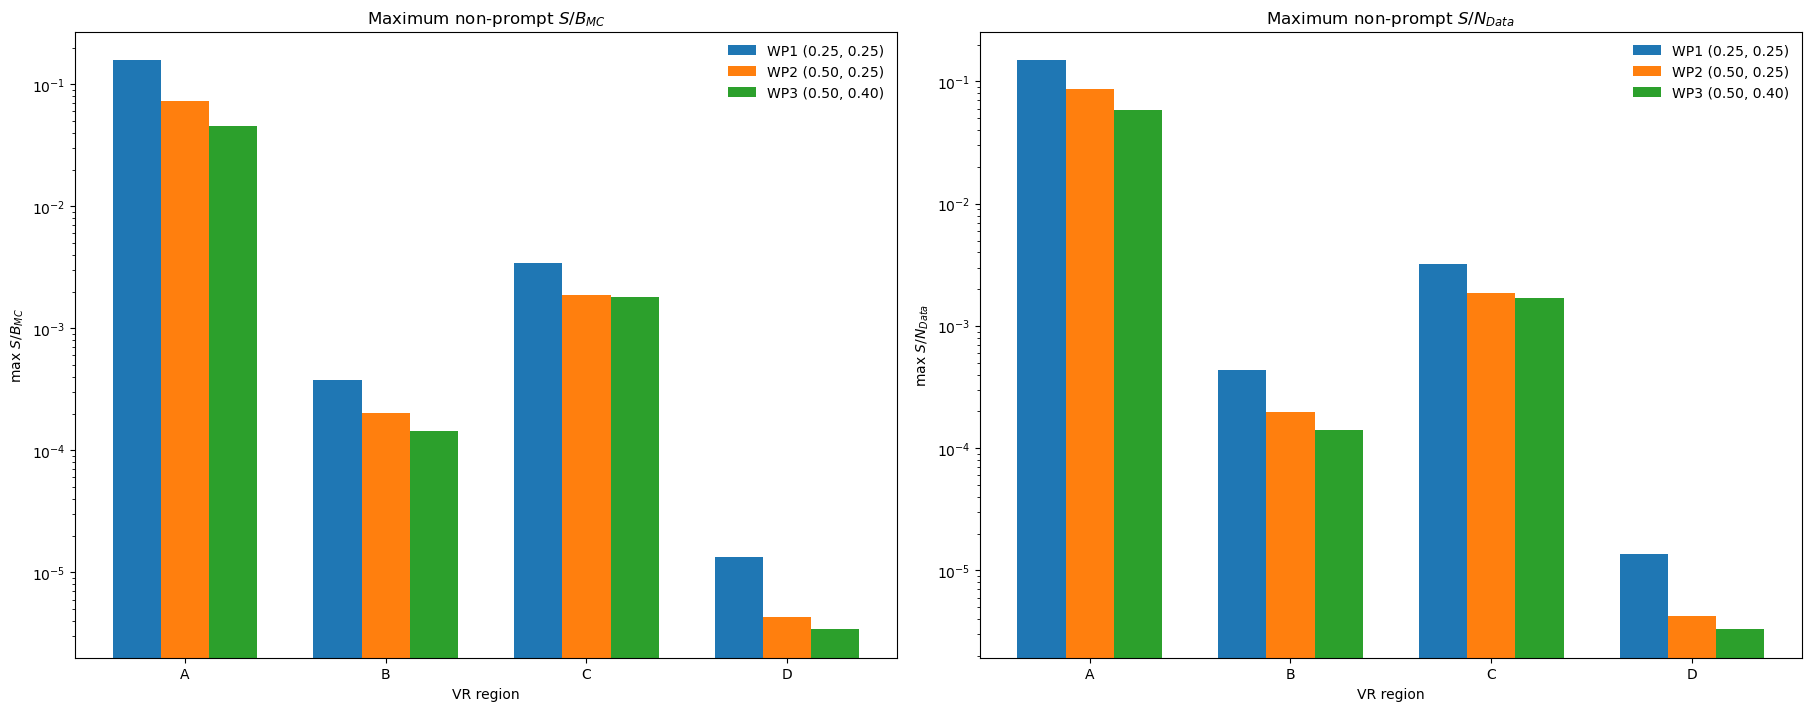

VR A: all signal points, ranked by S/B_MC within each WP


,wp,rank,signal,mean_Lxy_cm,VR_A_yield,VR_A_BkgMC_yield,VR_A_Data_yield,S_over_BkgMC_percent,S_over_Data_percent
135,"WP1 (0.25, 0.25)",1,2Mu2E_800GeV_0p25GeV_0p0025mm,0.3,150.986681,522.082398,551.0,28.920086,27.402301
150,"WP1 (0.25, 0.25)",2,2Mu2E_800GeV_1p2GeV_0p012mm,0.3,134.322097,522.082398,551.0,25.728141,24.377876
165,"WP1 (0.25, 0.25)",3,2Mu2E_800GeV_5p0GeV_0p05mm,0.3,125.196370,522.082398,551.0,23.980194,22.721664
138,"WP1 (0.25, 0.25)",4,2Mu2E_800GeV_0p25GeV_0p025mm,3.0,82.417688,522.082398,551.0,15.786337,14.957838
153,"WP1 (0.25, 0.25)",5,2Mu2E_800GeV_1p2GeV_0p12mm,3.0,71.722038,522.082398,551.0,13.737686,13.016704
136,"WP2 (0.50, 0.25)",1,2Mu2E_800GeV_0p25GeV_0p0025mm,0.3,151.397796,1139.962383,948.0,13.280947,15.970232
151,"WP2 (0.50, 0.25)",2,2Mu2E_800GeV_1p2GeV_0p012mm,0.3,134.818012,1139.962383,948.0,11.826532,14.221309
166,"WP2 (0.50, 0.25)",3,2Mu2E_800GeV_5p0GeV_0p05mm,0.3,125.978999,1139.962383,948.0,11.051154,13.288924
139,"WP2 (0.50, 0.25)",4,2Mu2E_800GeV_0p25GeV_0p025mm,3.0,82.646610,1139.962383,948.0,7.249942,8.717997
154,"WP2 (0.50, 0.25)",5,2Mu2E_800GeV_1p2GeV_0p12mm,3.0,72.002757,1139.962383,948.0,6.316240,7.595228


VR A: excluding the shortest-lifetime (Lxy = 0.3 cm) points


,wp,rank,signal,mean_Lxy_cm,VR_A_yield,VR_A_BkgMC_yield,VR_A_Data_yield,S_over_BkgMC_percent,S_over_Data_percent
138,"WP1 (0.25, 0.25)",1,2Mu2E_800GeV_0p25GeV_0p025mm,3.0,82.417688,522.082398,551.0,15.786337,14.957838
153,"WP1 (0.25, 0.25)",2,2Mu2E_800GeV_1p2GeV_0p12mm,3.0,71.722038,522.082398,551.0,13.737686,13.016704
168,"WP1 (0.25, 0.25)",3,2Mu2E_800GeV_5p0GeV_0p5mm,3.0,64.611044,522.082398,551.0,12.375641,11.726142
93,"WP1 (0.25, 0.25)",4,2Mu2E_500GeV_0p25GeV_0p04mm,3.0,15.802491,522.082398,551.0,3.026819,2.867966
108,"WP1 (0.25, 0.25)",5,2Mu2E_500GeV_1p2GeV_0p19mm,3.0,11.257135,522.082398,551.0,2.156199,2.043037
139,"WP2 (0.50, 0.25)",1,2Mu2E_800GeV_0p25GeV_0p025mm,3.0,82.646610,1139.962383,948.0,7.249942,8.717997
154,"WP2 (0.50, 0.25)",2,2Mu2E_800GeV_1p2GeV_0p12mm,3.0,72.002757,1139.962383,948.0,6.316240,7.595228
169,"WP2 (0.50, 0.25)",3,2Mu2E_800GeV_5p0GeV_0p5mm,3.0,64.984998,1139.962383,948.0,5.700627,6.854958
94,"WP2 (0.50, 0.25)",4,2Mu2E_500GeV_0p25GeV_0p04mm,3.0,15.848044,1139.962383,948.0,1.390225,1.671735
109,"WP2 (0.50, 0.25)",5,2Mu2E_500GeV_1p2GeV_0p19mm,3.0,11.327102,1139.962383,948.0,0.993638,1.194842


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7), constrained_layout=True)
regions = list("ABCD"); x = np.arange(len(regions)); width = 0.24
for index, wp in enumerate(wp_labels):
    frame = contamination_summary[contamination_summary.wp == wp].set_index("region").loc[regions]
    axes[0].bar(x + (index-1)*width, frame.max_S_over_BkgMC, width, label=wp)
    axes[1].bar(x + (index-1)*width, frame.max_S_over_Data, width, label=wp)
for ax, title, ylabel in [
    (axes[0], r"Maximum non-prompt $S/B_{MC}$", r"max $S/B_{MC}$"),
    (axes[1], r"Maximum non-prompt $S/N_{Data}$", r"max $S/N_{Data}$"),
]:
    ax.set_yscale("log"); ax.set_xticks(x, regions); ax.set(xlabel="VR region", ylabel=ylabel, title=title)
    ax.legend(frameon=False)
plt.show(); plt.close(fig)

def ranked_contamination_table(frame, n=5):
    ranked = pd.concat([
        frame[frame.wp == wp].nlargest(n, "VR_A_over_BkgMC")
        for wp in wp_labels
    ]).copy()
    ranked["rank"] = ranked.groupby("wp", sort=False).cumcount() + 1
    ranked["S_over_BkgMC_percent"] = 100 * ranked.VR_A_over_BkgMC
    ranked["S_over_Data_percent"] = 100 * ranked.VR_A_over_Data
    return ranked[[
        "wp", "rank", "signal", "mean_Lxy_cm", "VR_A_yield",
        "VR_A_BkgMC_yield", "VR_A_Data_yield",
        "S_over_BkgMC_percent", "S_over_Data_percent",
    ]]

print("VR A: all signal points, ranked by S/B_MC within each WP")
all_point_contamination = ranked_contamination_table(signal_summary, n=5)
display(all_point_contamination)

print("VR A: excluding the shortest-lifetime (Lxy = 0.3 cm) points")
nonprompt_contamination = ranked_contamination_table(nonprompt_signal, n=5)
display(nonprompt_contamination)


## 5. Relative SR-A signal yield

wp,"WP1 (0.25, 0.25) / WP1","WP2 (0.50, 0.25) / WP1","WP3 (0.50, 0.40) / WP1"
count,48.0,48.000000,48.000000
mean,1.0,1.007531,1.034216
std,0.0,0.006818,0.023582
min,1.0,1.001547,1.013553
10%,1.0,1.002750,1.015037
50%,1.0,1.005474,1.022713
90%,1.0,1.017156,1.074809
max,1.0,1.033803,1.104290


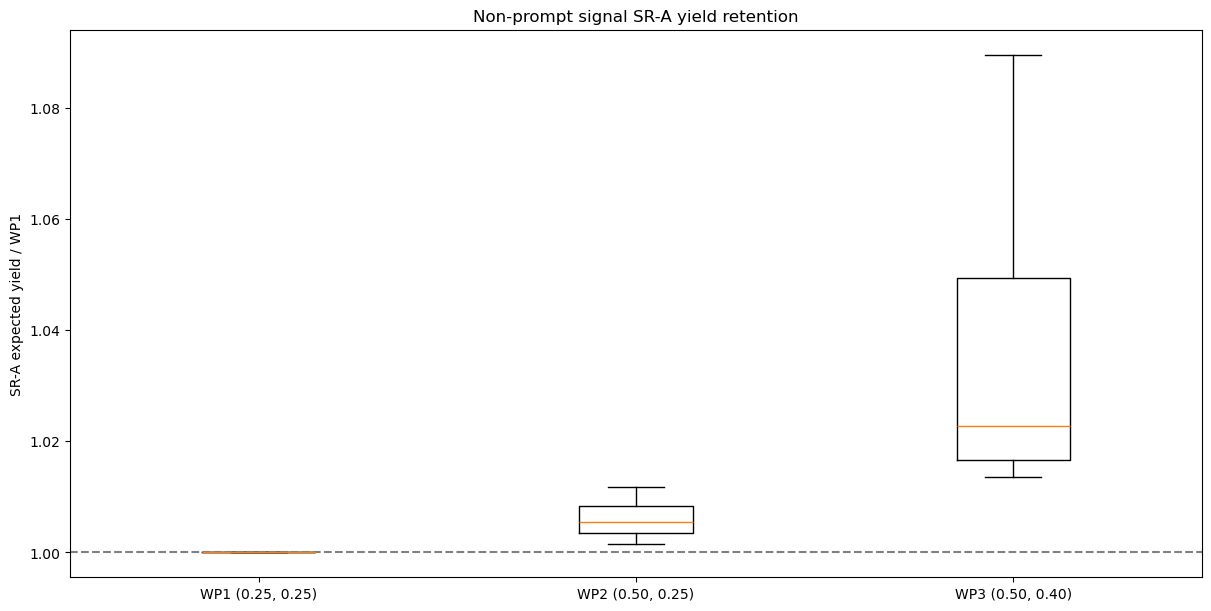

In [9]:
yield_table = nonprompt_signal.pivot(index="signal", columns="wp", values="SR_A_yield")
for wp in wp_labels:
    yield_table[f"{wp} / WP1"] = yield_table[wp] / yield_table[wp_labels[0]]
ratio_columns = [f"{wp} / WP1" for wp in wp_labels]
yield_ratio_summary = yield_table[ratio_columns].describe(percentiles=[0.1, 0.5, 0.9])
display(yield_ratio_summary)

fig, ax = plt.subplots(figsize=(12, 6), constrained_layout=True)
ratios = [yield_table[column].dropna().values for column in ratio_columns]
ax.boxplot(ratios, tick_labels=wp_labels, showfliers=False)
ax.axhline(1, color="gray", linestyle="--")
ax.set(ylabel="SR-A expected yield / WP1",
       title=r"Non-prompt signal SR-A yield retention")
plt.show(); plt.close(fig)


## 6. Combined comparison

In [10]:
combined_rows = []
for wp in wp_labels:
    closure = closure_summary[closure_summary.wp == wp].set_index("target")
    contamination = contamination_summary[contamination_summary.wp == wp].set_index("region")
    combined_rows.append({
        "wp": wp,
        "MC_SR_kappa": closure.loc["MC SR", "kappa"],
        "MC_SR_pull": closure.loc["MC SR", "pull"],
        "MC_VR_kappa": closure.loc["MC VR", "kappa"],
        "MC_VR_pull": closure.loc["MC VR", "pull"],
        "Data_VR_kappa": closure.loc["Data VR", "kappa"],
        "Data_VR_pull": closure.loc["Data VR", "pull"],
        "max_abs_pull": closure.pull.abs().max(),
        "max_nonprompt_VR_A_over_Data": contamination.loc["A", "max_S_over_Data"],
        "max_nonprompt_VR_BCD_over_Data": contamination.loc[list("BCD"), "max_S_over_Data"].max(),
        "median_SR_A_yield_over_WP1": yield_table[f"{wp} / WP1"].median(),
    })
combined_summary = pd.DataFrame(combined_rows)
display(combined_summary)


,wp,MC_SR_kappa,MC_SR_pull,MC_VR_kappa,MC_VR_pull,Data_VR_kappa,Data_VR_pull,max_abs_pull,max_nonprompt_VR_A_over_Data,max_nonprompt_VR_BCD_over_Data,median_SR_A_yield_over_WP1
0,"WP1 (0.25, 0.25)",15.802071,2.122839,0.871446,-0.252570,0.966846,-0.571766,2.122839,0.149578,0.003221,1.000000
1,"WP2 (0.50, 0.25)",1.575076,0.433005,1.138670,0.363345,0.942579,-1.072764,1.072764,0.087180,0.001878,1.005474
2,"WP3 (0.50, 0.40)",1.480950,0.365794,1.370342,0.729986,1.003179,0.064622,0.729986,0.058778,0.001688,1.022713
